## Fine-tuning a Model for Object Detection


Author: Nguyen Thanh Trung

### 0. Import packages

In [ ]:
# %pip install -U datasets transformers[torch] timm wandb torchmetrics matplotlib albumentations


In [1]:
import torch
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as F
from torch.utils.data import DataLoader
from datasets import Dataset, DatasetDict, Image, load_dataset


from transformers import TrainingArguments, Trainer, TrainerCallback

import os
import numpy as np
import PIL.Image
import random
import json
# import supervision as sv --> very good visualization package for Computer Vision --> check to use later on


import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as patches


from IPython.display import clear_output


import time
from sklearn.model_selection import train_test_split




/home/nur1hc/.conda/envs/langchain/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Create Custom dataset


#### Define id2label dictionary mapping the class integers to their class names

In [2]:
label2id = {
        "abriss" : 0,     
        "asperity" : 1,   
        "ausenriss" : 2,  
        "einriss" : 3,   
        "impression" : 4, 
        "oil" : 5,              
    }

id2label = {v: k for k, v in label2id.items()}

################################################################################
def hex_to_rgb(hex_code):
    hex_code = hex_code.lstrip('#')
    rgb = np.array([int(hex_code[i:i+2], 16) for i in (0, 2, 4)])
    return rgb

# color for plotting
id_colors = {
        0 :"#ff0000", # abriss
        1 :"#0091ff", # asperity 
        2 :"#ff00f7", # ausenriss
        3 :"#ffb980", # einriss
        4 :"#80ffea", # impression        
        5 :"#00ff00", # burning_oil
    }
id_colors_rgb = {k: hex_to_rgb(v) for k, v in id_colors.items()}
################################################################################


#### Extract bounding boxes from label-studio JSON

In [3]:
#############################################################################################
def get_image_paths(folder_path):
    image_paths = []
    for filename in os.listdir(folder_path):
        if filename.endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp')):  # Add more extensions if needed
            image_paths.append(os.path.join(folder_path, filename))
    return image_paths

#############################################################################################
def extract_bounding_boxes_from_label_studio(label_studio_json_path, image_paths):
    """
    Processes Label Studio JSON data to extract bounding box information for given images.

    Args:
        label_studio_json_path: Path to the Label Studio JSON file.
        image_paths: List of image paths to process.

    Returns:
        List of dictionaries, each containing image dimensions and extracted object information.
    """

    with open(label_studio_json_path, 'r') as f:
        label_data = json.load(f)

    results = []
    bbox_id = 0
    for idx, image_path in enumerate(image_paths):
        image_name = os.path.basename(image_path)
        objects = {'bbox_id': [],
                   'category': [],
                   'bbox': [],
                   'area': []}
        image = PIL.Image.open(image_path)
        width, height = image.size
        for task in label_data:
            if image_name in task['data']['image']:
                if task['annotations'][0]['result']:
                    for result in task['annotations'][0]['result']:
                        if result['type'] == 'rectanglelabels':
                            bbox_id += 1
                            objects['bbox_id'].append(bbox_id)
                            category = result['value']['rectanglelabels'][0]
                            category = label2id.get(category.replace("burning_", "").replace("material_lost_", ""))
                            objects['category'].append(category)
                            x, y, w, h = result['value']['x'], result['value']['y'], result['value']['width'], result['value']['height']
                            x1, y1, x2, y2 = int(x * width / 100), int(y * height / 100), int((x + w) * width / 100), int((y+h) * height / 100)
                            objects['bbox'].append([x1, y1, x2-x1, y2-y1])
                            objects['area'].append(int((x2-x1) * (y2-y1)))
                    break  
        results.append({
                        'image_id': idx,
                        'image_name': image_name,
                        'image': image,
                        'width': width,
                        'height': height,
                        'objects': objects
                    })
    return results

#############################################################################################
train_val_image_folder_path = "01_Images/OG/package2/image"
train_val_image_paths = sorted(get_image_paths(train_val_image_folder_path))
train_val_label_studio_json = "Label_Studio_JSON/package2_ausenris.json"

test_image_folder_path = "01_Images/OG/package3/image"
test_image_paths = sorted(get_image_paths(test_image_folder_path))
test_label_studio_json = "Label_Studio_JSON/package3.json"

train_val_images = extract_bounding_boxes_from_label_studio(train_val_label_studio_json, train_val_image_paths)
test_images = extract_bounding_boxes_from_label_studio(test_label_studio_json, test_image_paths)
print(f"No. train and validation images: {len(train_val_images)}")
print(f"No. test images: {len(test_images)}")
                                            

No. train and validation images: 900
No. test images: 997


In [4]:
# index = random.randint(1, len(train_val_images)-1)
# train_val_images[index:index+2]


In [5]:
# index = random.randint(1, len(test_images)-1)
# test_images[index:index+2]

#### Split images to train and validation sets 

40


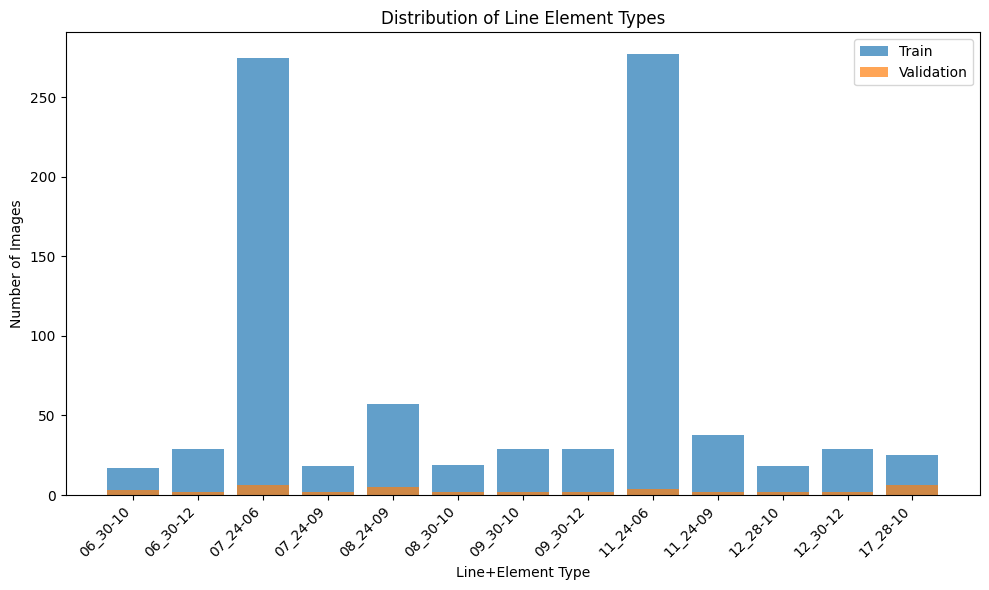

{'06_30-10': 3,
 '06_30-12': 2,
 '07_24-06': 6,
 '07_24-09': 2,
 '08_24-09': 5,
 '08_30-10': 2,
 '09_30-10': 2,
 '09_30-12': 2,
 '11_24-06': 4,
 '11_24-09': 2,
 '12_28-10': 2,
 '12_30-12': 2,
 '17_28-10': 6}

In [6]:
from sklearn.model_selection import train_test_split

random_state = 40
test_size = 0.035 # --> not use now, instead load the validation emial from file as below
#############################################################################################
# split the data using predefine name 
line_element_types = [os.path.basename(image_path)[:8] for image_path in train_val_image_paths]
with open("val_name_obdet.txt", 'r') as f:
    val_image_names = list(set(line.strip() for line in f.readlines()))
    
print(len(val_image_names))

train_images = [item for item in train_val_images if item['image_name'] not in val_image_names]
val_images = [item for item in train_val_images if item['image_name'] in val_image_names]

## # split the data using random split
# # train_images, val_images = train_test_split(
# #   train_val_images, 
# #   stratify=line_element_types, 
# #   test_size=test_size, 
# #   random_state=random_state
# # )
#############################################################################################
# Display the data distribution of split, check if distrubition is same
# Count occurrences for train and validation sets
train_type_counts = {t: [item['image_name'][:8] for item in train_images].count(t) for t in sorted(set(line_element_types))}
val_type_counts = {t: [item['image_name'][:8] for item in val_images].count(t) for t in sorted(set(line_element_types))}

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(train_type_counts.keys(), train_type_counts.values(), label='Train', alpha=0.7)
plt.bar(val_type_counts.keys(), val_type_counts.values(), label='Validation', alpha=0.7)

plt.xlabel("Line+Element Type")
plt.ylabel("Number of Images")
plt.title("Distribution of Line Element Types")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.legend()
plt.show()
val_type_counts

In [7]:
################################################################################
def create_dataset(images_list):
    data_dict = {
        'image_id': [item['image_id'] for item in images_list],
        'image_name': [item['image_name'] for item in images_list],
        'image': [item['image'] for item in images_list],
        'width': [item['width'] for item in images_list],
        'height': [item['height'] for item in images_list],
        'objects': [item['objects'] for item in images_list],
    }
    return Dataset.from_dict(data_dict)
################################################################################
# step 1: create Dataset objects
train_dataset = create_dataset(train_images)
val_dataset = create_dataset(val_images)
test_dataset = create_dataset(test_images)

# step 2: create DatasetDict
dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset,
})

################################################################################
dataset


DatasetDict({
    train: Dataset({
        features: ['image_id', 'image_name', 'image', 'width', 'height', 'objects'],
        num_rows: 860
    })
    validation: Dataset({
        features: ['image_id', 'image_name', 'image', 'width', 'height', 'objects'],
        num_rows: 40
    })
    test: Dataset({
        features: ['image_id', 'image_name', 'image', 'width', 'height', 'objects'],
        num_rows: 997
    })
})

In [8]:
#have a look on validation image and its label
for i, item in enumerate(dataset['validation']):
    print(f"{i}: {item['image_name']} - {item['width']},{item['height']} - {[id2label.get(id) for id in item['objects']['category']]}")


0: 06_30-10_IMG_LOG__CAM_2_20231208_125650_584.jpg - 1024,760 - ['impression']
1: 06_30-10_IMG_LOG__CAM_2_20231208_125715_421.jpg - 1024,760 - ['einriss']
2: 06_30-10_IMG_LOG__CAM_2_20231208_184058_523.jpg - 1024,760 - ['einriss', 'abriss', 'abriss']
3: 06_30-12_IMG_LOG__CAM_1_20240629_171437_366.jpg - 1024,760 - ['oil']
4: 06_30-12_IMG_LOG__CAM_1_20240629_171651_682.jpg - 1024,760 - ['einriss', 'oil', 'oil']
5: 07_24-06_IMG_LOG__CAM_1_20231211_220021_092.jpg - 1296,600 - ['impression']
6: 07_24-06_IMG_LOG__CAM_1_20231211_223239_074.jpg - 1296,600 - ['impression', 'abriss']
7: 07_24-06_IMG_LOG__CAM_2_20231211_215944_772.jpg - 1296,600 - ['impression', 'abriss', 'abriss', 'abriss', 'abriss']
8: 07_24-06_IMG_LOG__CAM_2_20240112_234952_027.jpg - 1296,600 - ['oil', 'oil', 'oil', 'oil', 'oil']
9: 07_24-06_IMG_LOG__CAM_2_20240120_074749_796.jpg - 1296,600 - ['impression', 'einriss', 'einriss']
10: 07_24-06_IMG_LOG__CAM_2_20240120_151654_584.jpg - 1296,600 - ['abriss', 'abriss', 'abriss', 'ab

In [9]:
index = random.randint(0, len(dataset['validation'])-1)
index = 12
dataset['validation'][index]

{'image_id': 347,
 'image_name': '07_24-09_IMG_LOG__CAM_2_20240315_171002_924.jpg',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1296x600>,
 'width': 1296,
 'height': 600,
 'objects': {'area': [3332],
  'bbox': [[175, 319, 68, 49]],
  'bbox_id': [752],
  'category': [5]}}

#### Visualize dataset

In [10]:
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as patches
def visualize_image_bboxes(image, image_name=None, 
                           class_ids=None, bboxes=None, bbox_coco_format=True,
                           pred_class_ids=None, pred_bboxes=None, pred_scores = None, pred_bbox_coco_format=False,
                           id_colors_rgb=None, id2label=None,
                           
                           show_orginal_image=False, 
                           save_path=None,
                           show_plot=True,
                           show_both_label_pred=False):

    pixel_mm_scale = {
        6: [0.0116, 0.0165],
        8: [0.0116, 0.0165],
        7: [0.0094, 0.0143],
        9: [0.0094, 0.0143],
        10: [0.0094, 0.0143],
        11: [0.0094, 0.0143],
        12: [0.0094, 0.0143],
        17: [0.0094, 0.0143],
    }
    
    #-------------Image Info---------------#
#     print(f"Image shape: {image.numpy().shape}")
    if torch.is_tensor(image):
        image_np = image.permute(1, 2, 0).clone().mul(255).to(torch.uint8).numpy()
    else:
        image_np = image 
    #print(f"Image unique values: {np.unique(image.numpy())}")
    
      
    #-------------bboxes and pred bboxes---------------#
    if torch.is_tensor(bboxes):
        bboxes = bboxes.numpy()
    has_bboxes = bboxes is not None
    
    if torch.is_tensor(pred_bboxes):
        pred_bboxes = pred_bboxes.numpy()
    has_pred_bboxes = pred_bboxes is not None
    
    class_names = []
    
    #-------------legend_elements---------------#
    legend_elements = [Patch(facecolor=id_colors_rgb[class_id] / 255, 
                         edgecolor='black', label=id2label[class_id]) 
                   for class_id in id_colors_rgb if class_id != 0]
    
    #-------------Plot---------------#
    if has_bboxes or has_pred_bboxes:
        num_subplots = int(has_bboxes or show_both_label_pred) + int(has_pred_bboxes or show_both_label_pred) + int(show_orginal_image)
        plt.figure(figsize=(10, num_subplots*5))
        if show_orginal_image:
            plt.subplot(num_subplots, 1, 1)
            plt.imshow(image_np)
            plt.title(f"{image_name if image_name else 'Image'}", fontsize=10)
        
        if has_bboxes or show_both_label_pred:
            plt.subplot(num_subplots, 1, int(show_orginal_image) + 1)
            plt.imshow(image_np)
            plt.title(f"{image_name if image_name else 'Image'} with True Labels", fontsize=10)
#             plt.legend(handles=legend_elements, bbox_to_anchor=(1, 0), 
#                     loc='lower right',  ncol=3, fontsize=8)
            
            # Draw bounding boxes on the original image
            if has_bboxes:
                for bbox, class_id in zip(bboxes, class_ids):
                    if bbox_coco_format:
                        x1, y1, w, h = bbox
                    else:
                        x1, y1, x2, y2 = bbox
                        w = x2-x1
                        h = y2-y1
                    color = id_colors_rgb[class_id] / 255
                    rect = patches.Rectangle((x1, y1), w, h, linewidth=1, edgecolor=color, facecolor='none')
                    plt.gca().add_patch(rect)
                    # Add class label as text on top of the bounding box
                    plt.text(x1, y1 - 5, f"{id2label[class_id]}", color=color, fontsize=8)
                    
        if has_pred_bboxes or show_both_label_pred:
            plt.subplot(num_subplots, 1, num_subplots)
            plt.imshow(image_np)
           
            plt.title(f"{image_name if image_name else 'Image'} with Predicted Labels", fontsize=10)
#             plt.legend(handles=legend_elements, bbox_to_anchor=(1, 0), 
#                        loc='lower right',  ncol=3, fontsize=8)
            # Draw bounding boxes on the original image
            if has_pred_bboxes:
                for bbox, class_id, pred_score in zip(pred_bboxes, pred_class_ids, pred_scores):
                    if pred_bbox_coco_format:
                        x1, y1, w, h = bbox
                    else:
                        x1, y1, x2, y2 = bbox
                        w = x2-x1
                        h = y2-y1
                    class_names.append(id2label[class_id])
                    color = id_colors_rgb[class_id] / 255
                    rect = patches.Rectangle((x1, y1), w, h, linewidth=1, edgecolor=color, facecolor='none')
                    plt.gca().add_patch(rect)
                    line = int(image_name[:2])
                    w_mm = w * pixel_mm_scale.get(line,[0,0])[0]
                    h_mm = h * pixel_mm_scale.get(line,[0,0])[1]
#                     Add class label as text on top of the bounding box
                    plt.text(x1, y1 - 15, f"{id2label[class_id]}\np={pred_score:.2f}\nw={w_mm:.2f}, h={h_mm:.2f}" if pred_score else f"{id2label[class_id]}", color=color, fontsize=8)
    
    str_class_names = "_".join(set(class_names))
    if image_name:
        image_name = image_name.replace(".jpg","")
        pic_name=f"{image_name if image_name else 'Image'}_{str_class_names}.png"
    else:
        pic_name = "Image" 
    if save_path:
        plt.savefig(os.path.join(save_path,pic_name))
    if show_plot:
        plt.show()
    else:
        plt.close()

Visualize Label of image: 11_24-06_IMG_LOG__CAM_2_20240608_094159_652.jpg


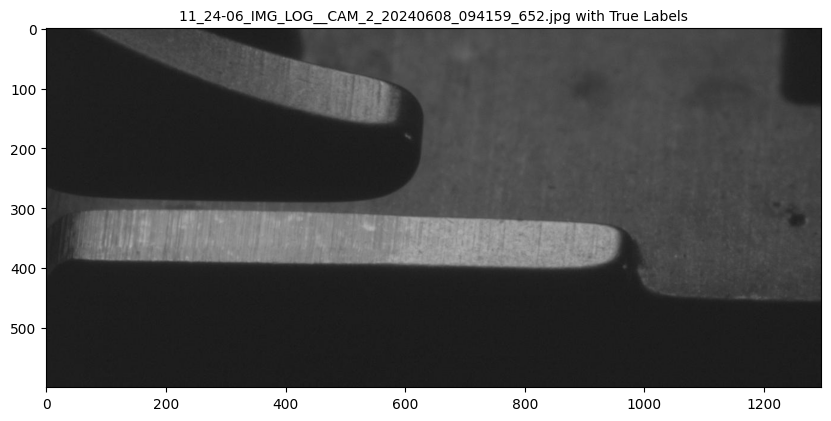

In [11]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont

# Load image and annotations
index = random.randint(0, len(dataset['train'])-1)
image = dataset['train'][index]["image"]
image_name = dataset['train'][index]['image_name']
bboxes = dataset['train'][index]["objects"]['bbox']
class_ids = dataset['train'][index]["objects"]['category']


################################################################################
print(f"Visualize Label of image: {image_name}")
visualize_image_bboxes(image, image_name=image_name,
                       class_ids=class_ids, bboxes=bboxes,
                       id_colors_rgb=id_colors_rgb, id2label=id2label)




### 2. Preprocess the data


set Proxy to load pre-trained model from Hugging-Face

In [12]:
import os
# Setting the environment variables
os.environ['HTTP_PROXY'] = 'http://rb-proxy-sl.bosch.com:8080'
os.environ['HTTPS_PROXY'] = 'http://rb-proxy-sl.bosch.com:8080'
os.environ['NO_PROXY'] = 'localhost,127.0.0.1,127.*,::1,172.16.*,172.17.*,172.18.*,172.19.*,172.20.*,172.21.*,172.22.*,172.23.*,172.24.*,172.25.*,172.26.*,172.27.*,172.28.*,172.29.*,172.30.*,172.31.*,192.168.*,10.*,de.bosch.com,apac.bosch.com,emea.bosch.com,us.bosch.com,rb-artifactory.bosch.com,sourcecode01.de.bosch.com,sourcecode.socialcoding.bosch.com'
# Verifying the environment variables are set
print("HTTP_PROXY:", os.environ.get('HTTP_PROXY'))
print("HTTPS_PROXY:", os.environ.get('HTTPS_PROXY'))
print("NO_PROXY:", os.environ.get('NO_PROXY'))

HTTP_PROXY: http://rb-proxy-sl.bosch.com:8080
HTTPS_PROXY: http://rb-proxy-sl.bosch.com:8080
NO_PROXY: localhost,127.0.0.1,127.*,::1,172.16.*,172.17.*,172.18.*,172.19.*,172.20.*,172.21.*,172.22.*,172.23.*,172.24.*,172.25.*,172.26.*,172.27.*,172.28.*,172.29.*,172.30.*,172.31.*,192.168.*,10.*,de.bosch.com,apac.bosch.com,emea.bosch.com,us.bosch.com,rb-artifactory.bosch.com,sourcecode01.de.bosch.com,sourcecode.socialcoding.bosch.com


#### Load image processor from HuggingFace

Uncomment block below to load model from `hugging face` and save it to folder `03_Models` for using next time

In [13]:
# from transformers import AutoModelForObjectDetection
# checkpoint = "PekingU/rtdetr_v2_r34vd"
# model = AutoModelForObjectDetection.from_pretrained(
#     checkpoint,
#     id2label=id2label,
#     label2id=label2id,
#     ignore_mismatched_sizes=True,
# )
# image_processor.save_pretrained(checkpoint.replace("PekingU","03_Models"))
# model.save_pretrained(checkpoint.replace("PekingU","03_Models"))

In [14]:
checkpoint = "03_Models/rtdetr_v2_r18vd"
# checkpoint = "03_Models/rtdetr_v2_r34vd"
# checkpoint = "03_Models/rtdetr_v2_r50vd"
# checkpoint = "PekingU/rtdetr_v2_r34vd"

SIZE_X = 640
SIZE_Y = 480

In [15]:
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained(
    checkpoint,
    do_resize=True,
    size={"width": SIZE_X, "height": SIZE_Y},
    use_fast=False
)


#### Augmenting images

Before passing the images to the image_processor, apply two preprocessing transformations to the dataset:

* Augmenting images
* Reformatting annotations to meet RT-DETR expectations


In [16]:
import albumentations as A
import cv2
rotate_angle = 10
zoom_scale = 0.9
train_augmentation_and_transform = A.Compose(
    [
        # A.Perspective(p=0.1),  
        # A.RandomScale(scale_limit=(1.0, 0.95), interpolation=cv2.INTER_LINEAR, p=0.1), 
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), p=0.5),
        A.HueSaturationValue(hue_shift_limit=(-0.1, 0.1), sat_shift_limit=(-0.1, 0.1), val_shift_limit=(-0.1, 0.1), p=0.2),
        # A.GaussianBlur(blur_limit=(5, 7), p=1),
        A.Rotate(limit=(-rotate_angle,rotate_angle), p=0.2),
        A.Affine(scale=(1.0, zoom_scale), translate_px={"y": (-120, 100),"x": 0}, rotate=(-0, 0), shear={"y": (-10, 10),"x": (0, 0)}, p=0.5)

    ],
    bbox_params=A.BboxParams(format="coco", label_fields=["category"], clip=True, min_area=8, min_width=1, min_height=1),
    seed=42  # Set your desired seed here
)

# to make sure boxes are clipped to image size and there is no boxes with area < 1 pixel
validation_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(format="coco", label_fields=["category"], clip=True, min_area=1, min_width=1, min_height=1),
)

/home/nur1hc/.conda/envs/langchain/lib/python3.11/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: '2.0.4' (you have '2.0.0'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Visualize some augmented images to make sure images look natural and annotations are correct:



173
Visualization of augmented, transformed train image


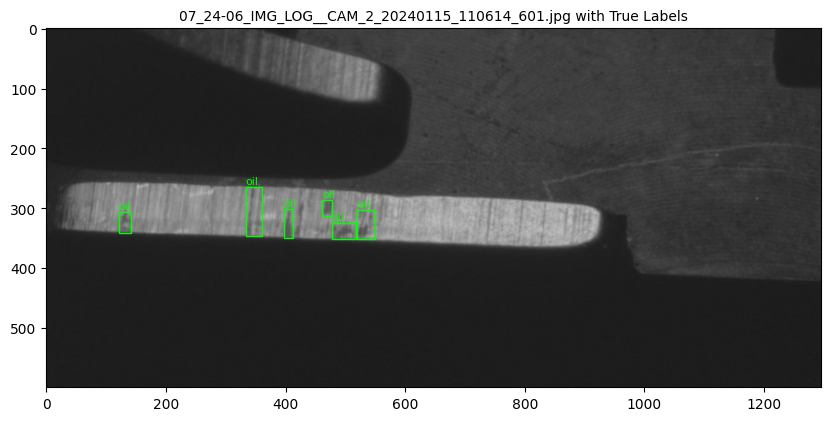

--------------------------------------------------
Visualization of transformed val image


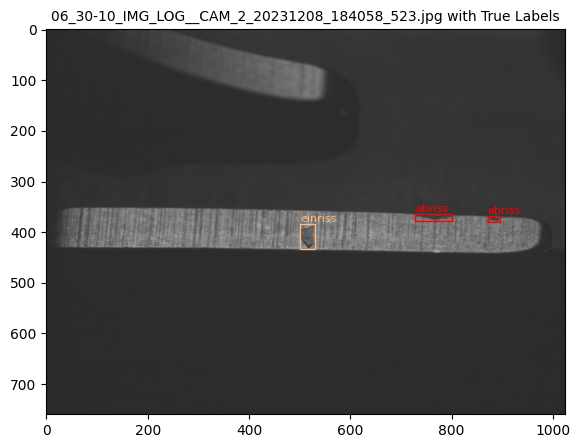

In [17]:
index = random.randint(0,len(dataset['train'])-1)
# index=481
print(index)
image = dataset['train'][index]["image"]
image_name = dataset['train'][index]['image_name']
bboxes = dataset['train'][index]["objects"]['bbox']
class_ids = dataset['train'][index]["objects"]['category']

# Apply the augmentations
output = train_augmentation_and_transform(image=np.array(image), bboxes=bboxes, category=class_ids)
# Unpack the output
image = Image.fromarray(output["image"])
class_ids, bboxes = output["category"], output["bboxes"]
print(f"Visualization of augmented, transformed train image")
visualize_image_bboxes(image, image_name=image_name,
                       class_ids=class_ids, bboxes=bboxes,
                       id_colors_rgb=id_colors_rgb, id2label=id2label)

################################################################################
print("-"*50)
print(f"Visualization of transformed val image")
index = random.randint(0,len(dataset['validation'])-1)
image = dataset['validation'][index]["image"]
image_name = dataset['validation'][index]['image_name']
bboxes = dataset['validation'][index]["objects"]['bbox']
class_ids = dataset['validation'][index]["objects"]['category']

# Apply the augmentations
output = validation_transform(image=np.array(image), bboxes=bboxes, category=class_ids)
# Unpack the output
image = Image.fromarray(output["image"])
class_ids, bboxes = output["category"], output["bboxes"]

#Visualization
visualize_image_bboxes(image, image_name=image_name,
                       class_ids=class_ids, bboxes=bboxes,
                       id_colors_rgb=id_colors_rgb, id2label=id2label)

#### Reformatting annotations

The image_processor expects the annotations to be in the following format: 
`{'image_id': int, 'annotations': List[Dict]}`
where each dictionary is a COCO object annotation. Let's add a function to reformat annotations for a single example:



In [18]:
from torch.utils.data import Dataset


class AOIDataset(Dataset):
    def __init__(self, data, image_processor, transforms=None):
        self.data = data
        self.image_processor = image_processor
        self.transforms = transforms

    @staticmethod
    def format_annotations_as_coco(image_id, categories, bounding_boxes):
        """
        Formats image annotations into COCO format.

        Args:
            image_id (str): Image identifier.
            categories (List[int]): List of category labels for bounding boxes.
            bounding_boxes (List[Tuple[float]]): List of bounding boxes in COCO format
                ([center_x, center_y, width, height] in absolute coordinates).

        Returns:
            dict: COCO-formatted annotations.
        """
        annotations = []
        for category, box in zip(categories, bounding_boxes):
            formatted_annotation = {
                "image_id": image_id,
                "category_id": category,
                "bbox": list(box),
                "iscrowd": 0,
                "area": box[2] * box[3],
            }
            annotations.append(formatted_annotation)

        return {
            "image_id": image_id,
            "annotations": annotations,
        }

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        sample = self.data[index]

        image_id = sample["image_id"]
        image = sample["image"]
        boxes = sample["objects"]["bbox"]
        categories = sample["objects"]["category"]

        # Convert image to RGB NumPy array
        image = np.array(image.convert("RGB"))
        # image = np.array(image)

        # Apply augmentations
        if self.transforms:
            transformed = self.transforms(image=image, bboxes=boxes, category=categories)
            image = transformed["image"]
            boxes = transformed["bboxes"]
            categories = transformed["category"]

        # Format annotations in COCO format for image processor
        formatted_annotations = self.format_annotations_as_coco(image_id, categories, boxes)

        # Apply image processor transformations: resizing, rescaling, normalization
        result = self.image_processor(
            images=image, annotations=formatted_annotations, return_tensors="pt"
        )

        # Squeeze batch dimension from image processor output
        result = {k: v[0] for k, v in result.items()}

        return result

In [19]:
train_dataset = AOIDataset(dataset["train"], image_processor, transforms=train_augmentation_and_transform)
validation_dataset = AOIDataset(dataset["validation"], image_processor, transforms=validation_transform)
test_dataset = AOIDataset(dataset["test"], image_processor, transforms=validation_transform)

train_dataset[154]


{'pixel_values': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 'labels': {'size': tensor([480, 640]), 'image_id': tensor([163]), 'class_labels': tensor([0, 5, 5]), 'boxes': tensor([[0.8804, 0.3485, 0.0667, 0.0366],
         [0.8357, 0.4

#### Checking all transformations

Apply this preprocessing function to the entire dataset using 🤗 Datasets with_transform method. This method applies transformations on the fly when you load an element of the dataset.

At this point, you can check what an example from the dataset looks like after the transformations. You should see a tensor with pixel_values, a tensor with pixel_mask, and labels.

Check images once again after applying the all the transformations, verify that boxes and labels are correct!

In [20]:
def denormalize_image(image):
    mean = image_processor.image_mean
    std = image_processor.image_std
    for i, m, s in zip(image, mean, std):
        i.mul_(s).add_(m)
    return image

554
Image tensor shape: (480, 640, 3)
BBoxes shape: (1, 4)
Class_ids shape: (1,)


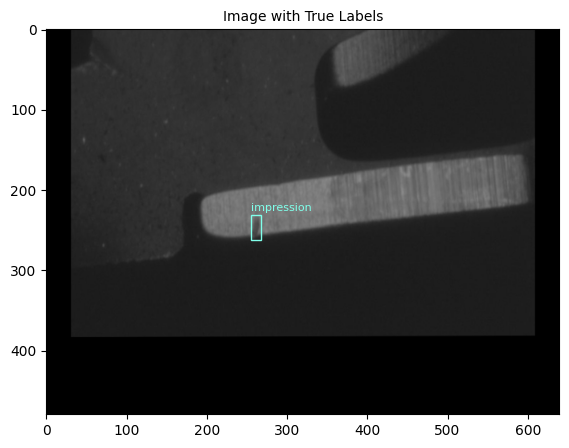

In [21]:
index = random.randint(0,len(dataset['train'])-1)
print(index)
sample = train_dataset[index]
# De-normalize image
image = sample["pixel_values"]
# image = denormalize_image(image) # uncomment it to see original picture incase apply normalize in image_processor


image = image.permute(1, 2, 0).clone().mul(255).to(torch.uint8).numpy()
print("Image tensor shape:", image.shape)

# Convert boxes from [center_x, center_y, width, height] to [x, y, width, height] for visualization
bboxes = sample["labels"]["boxes"].numpy()
print("BBoxes shape:", bboxes.shape)
bboxes[:, :2] = bboxes[:, :2] - bboxes[:, 2:] / 2
h,w = image.shape[:2]
bboxes = bboxes * np.array([w, h, w, h])[None]

class_ids = sample["labels"]["class_labels"].numpy()
print("Class_ids shape:", class_ids.shape)

visualize_image_bboxes(image, image_name=None,
                       class_ids=class_ids, bboxes=bboxes,
                       id_colors_rgb=id_colors_rgb, id2label=id2label)

#### Create custom collate_fn

You have successfully augmented the images and prepared their annotations. In the final step, create a custom `collate_fn` to batch images together.

In [22]:
import torch

def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    return data

### 3. Preparing function to compute mAP


Object detection models are commonly evaluated with a set of COCO-style metrics. We are going to use torchmetrics to compute mAP (mean average precision) and mAR (mean average recall) metrics and will wrap it to compute_metrics function in order to use in Trainer for evaluation.

Intermediate format of boxes used for training is YOLO (normalized) but we will compute metrics for boxes in Pascal VOC (absolute) format in order to correctly handle box areas. Let's define a function that converts bounding boxes to Pascal VOC format:

In [23]:
from transformers.image_transforms import center_to_corners_format

def convert_bbox_yolo_to_pascal(boxes, image_size):
    """
    Convert bounding boxes from YOLO format (x_center, y_center, width, height) in range [0, 1]
    to Pascal VOC format (x_min, y_min, x_max, y_max) in absolute coordinates.

    Args:
        boxes (torch.Tensor): Bounding boxes in YOLO format
        image_size (Tuple[int, int]): Image size in format (height, width)

    Returns:
        torch.Tensor: Bounding boxes in Pascal VOC format (x_min, y_min, x_max, y_max)
    """
    # convert center to corners formata
    boxes = center_to_corners_format(boxes)

    # convert to absolute coordinates
    height, width = image_size
    boxes = boxes * torch.tensor([[width, height, width, height]])

    return boxes

Then, in compute_metrics function we collect predicted and target bounding boxes, scores and labels from evaluation loop results and pass it to the scoring function.

In [24]:
import numpy as np
from dataclasses import dataclass
from torchmetrics.detection.mean_ap import MeanAveragePrecision


@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor


class MAPEvaluator:

    def __init__(self, image_processor, threshold=0.00, id2label=None):
        self.image_processor = image_processor
        self.threshold = threshold
        self.id2label = id2label
        self.excluded_class_id = 5  # Class ID to exclude: oil

    def collect_image_sizes(self, targets):
        """Collect image sizes across the dataset as list of tensors with shape [batch_size, 2]."""
        image_sizes = []
        for batch in targets:
            batch_image_sizes = torch.tensor(np.array([x["size"] for x in batch]))
            image_sizes.append(batch_image_sizes)
        return image_sizes

    def collect_targets(self, targets, image_sizes):
        post_processed_targets = []
        for target_batch, image_size_batch in zip(targets, image_sizes):
            for target, size in zip(target_batch, image_size_batch):
                boxes = torch.tensor(target["boxes"])
                boxes = convert_bbox_yolo_to_pascal(boxes, size)
                labels = torch.tensor(target["class_labels"])
                post_processed_targets.append({"boxes": boxes, "labels": labels})
        return post_processed_targets

    def collect_predictions(self, predictions, image_sizes):
        post_processed_predictions = []
        for batch, target_sizes in zip(predictions, image_sizes):
            batch_logits, batch_boxes = batch[1], batch[2]
            output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
            post_processed_output = self.image_processor.post_process_object_detection(
                output, threshold=self.threshold, target_sizes=target_sizes
            )
            post_processed_predictions.extend(post_processed_output)
        return post_processed_predictions

    @torch.no_grad()
    def __call__(self, evaluation_results):

        predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

        image_sizes = self.collect_image_sizes(targets)
        post_processed_targets = self.collect_targets(targets, image_sizes)
        post_processed_predictions = self.collect_predictions(predictions, image_sizes)

        evaluator = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
        evaluator.warn_on_many_detections = False
        evaluator.update(post_processed_predictions, post_processed_targets)

        metrics = evaluator.compute()

        # Replace list of per class metrics with separate metric for each class
        classes = metrics.pop("classes")
        map_per_class = metrics.pop("map_per_class")
        mar_100_per_class = metrics.pop("mar_100_per_class")
        for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
            class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
            metrics[f"map_{class_name}"] = class_map
            metrics[f"mar_100_{class_name}"] = class_mar

        # Calculate eval_map and eval_mar_1 excluding the specified class
        eval_map_excld_1 = torch.mean(torch.tensor([map_per_class[i] for i, c in enumerate(classes) if c != 1]))
        metrics["eval_map_excld_1"] = eval_map_excld_1
        
        # Calculate eval_map and eval_mar_1 excluding the specified class
        eval_mar_map = torch.mean(torch.tensor([mar_100_per_class[i] for i, c in enumerate(classes) if c != self.excluded_class_id] + [map_per_class[self.excluded_class_id]]))
        metrics["eval_mar_map"] = eval_mar_map
        metrics["eval_F1"] = 2/(1/metrics["map"]+1/metrics["mar_100"])
        
        metrics = {k: round(v.item(), 4) for k, v in metrics.items()}

        return metrics

###########################
# calculate the metric of boxes has confidence score > threshold only, can be start with 0.01
threshold=0.1
eval_compute_metrics_fn = MAPEvaluator(image_processor=image_processor, threshold=threshold, id2label=id2label)

### 4. Training the detection model


Training involves the following steps:

* Load the model with `AutoModelForObjectDetection` using the same checkpoint as in the preprocessing.
* Define your training hyperparameters in `TrainingArguments`.
* Pass the training arguments to `Trainer` along with the model, dataset, image processor, and data collator.
* Call `train()` to finetune your model.

In [26]:
from transformers import AutoModelForObjectDetection, RTDetrForObjectDetection
from transformers import AutoConfig
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# checkpoint = "03_Models/rtdetr_v2_r50vd"
# checkpoint = "03_Models/rtdetr_v2_r34vd"
checkpoint = "03_Models/rtdetr_v2_r18vd"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_config  = AutoConfig.from_pretrained(checkpoint)

# model_config.use_pretrained_backbone=True # consider this if dont want to use RTDETR model wighted loaded from Hugging face, but still want to use pretrained backbone
# model_config.backbone = "microsoft/resnet-18"


# model_config.encoder_layers = 1 
model_config.decoder_layers = 4

model_config.num_queries = 50  # Reduce form 300 to 50 bboxes only, it is enough for use case of 6 clasess
model_config.box_noise_scale= 0.0 # set to 0 due to good quality of labels of bounding boxes, dont need to create more noise for model to learn, focus to learn the pattens within dataset
model_config.label_noise_ratio =  0.0 # set to 0 due to good quality of labels of bounding boxes, dont need to create more noise for model to learn, focus to learn the pattens within dataset
model_config.dropout = 0.1 # set to 0 or increase slightly if needed

# model_config.matcher_bbox_cost=  5.0
model_config.matcher_class_cost= 8.0 # increase this compare to default value to ask model more prioritize to learn the correct classes than size of boxes
# model_config.weight_loss_bbox = 5.0
# model_config.weight_loss_giou = 5.0
# # model_config.num_denoising = 10

model = AutoModelForObjectDetection.from_pretrained(checkpoint, 
                                                    config=model_config,
                                                   ignore_mismatched_sizes=True,).to(DEVICE)



Could not load the custom kernel for multi-scale deformable attention: CUDA_HOME environment variable is not set. Please set it to your CUDA install root.
Could not load the custom kernel for multi-scale deformable attention: /home/nur1hc/.cache/torch_extensions/py311_cu121/MultiScaleDeformableAttention/MultiScaleDeformableAttention.so: cannot open shared object file: No such file or directory
Could not load the custom kernel for multi-scale deformable attention: /home/nur1hc/.cache/torch_extensions/py311_cu121/MultiScaleDeformableAttention/MultiScaleDeformableAttention.so: cannot open shared object file: No such file or directory
Could not load the custom kernel for multi-scale deformable attention: /home/nur1hc/.cache/torch_extensions/py311_cu121/MultiScaleDeformableAttention/MultiScaleDeformableAttention.so: cannot open shared object file: No such file or directory
Some weights of RTDetrV2ForObjectDetection were not initialized from the model checkpoint at 03_Models/rtdetr_v2_r18vd 

In [29]:
backbone = model.model.backbone
total_params = sum(p.numel() for p in model.parameters())
total_params

21209618

In [41]:
# Separate parameters
backbone_params = list(param for name, param in model.named_parameters() if 'backbone' in name)
other_params = list(param for name, param in model.named_parameters() if 'backbone' not in name)
# model.config
#set different learning rate for backbone and others, play around 1e-5 to 1e-4. 
optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 5e-5},  # Lower learning rate for backbone
    {'params': other_params, 'lr': 1e-4}   # Higher learning rate for the rest

])

In [38]:
###Freeze backbone if you want

# # Identify and freeze the backbone
# for name, param in model.named_parameters():
#     if "backbone" in name:
#         print(name)
#         param.requires_grad = False
# # Get the backbone model (usually a ResNet)



In the TrainingArguments use output_dir to specify where to save your model, then configure hyperparameters as you see fit.

Important notes:

* Do not remove unused columns because this will drop the image column. Without the image column, you can't create `pixel_values`. For this reason, set `remove_unused_columns` to False.
* Set 'eval_do_concat_batches=False' to get proper evaluation results. Images have different number of target boxes, if batches are concatenated we will not be able to determine which boxes belongs to particular image.

In [42]:

from transformers import TrainingArguments, Trainer, AdamW

current_date = time.strftime("%Y-%m-%d_%H-%M-%S") #time.strftime("%Y-%m-%d_%H-%M-%S")

training_args = TrainingArguments(
    output_dir=f"{checkpoint}/Checkpoints/{current_date}",
    logging_dir="03_Models/logs",
    num_train_epochs=50,
    max_grad_norm=0.1,
    # learning_rate=1e-4, # done use now due to diffrent leraning rates
    warmup_steps=300,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=40,
    dataloader_num_workers=4,
    metric_for_best_model="eval_map_excld_1",#"eval_mar_map", #"eval_map", # change metrics if you want
    greater_is_better=True,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
    report_to=[],
    fp16=True,  # Use mixed precision training for faster training and reduced memory
    dataloader_pin_memory=True,
    # gradient_accumulation_steps=1,  # Simulate larger batch size without increasing memory
    weight_decay=1e-4,  # Add weight decay to prevent overfitting
    # lr_scheduler_type="cosine",  # Cosine annealing often performs well
    seed=42,  # Set a seed for reproducibility
)


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    tokenizer=image_processor,
    data_collator=collate_fn,
    compute_metrics=eval_compute_metrics_fn,
    optimizers=(optimizer, None)
)

trainer.train()

In [35]:
# # Save the final trained model
current_date = time.strftime("%Y-%m-%d_%H-%M-%S") #time.strftime("%Y-%m-%d_%H-%M-%S")
model_name = f"RT-DETRV2_{SIZE_X}_{SIZE_Y}_th{threshold}_z{zoom_scale}_r{rotate_angle}_{current_date}"
model_save_path = f"{checkpoint}/{model_name}"
model.config.model_type='rt_detr'
trainer.save_model(model_save_path)
image_processor.save_pretrained(model_save_path)

model.config.save_pretrained(model_save_path)


### 5. Evaluate

In [36]:
from pprint import pprint

metrics = trainer.evaluate(eval_dataset=validation_dataset, metric_key_prefix="eval")
pprint(metrics)

{'eval_F1': 0.0,
 'eval_loss': 65.93656158447266,
 'eval_map': 0.0,
 'eval_map_50': 0.0,
 'eval_map_75': 0.0,
 'eval_map_abriss': 0.0,
 'eval_map_asperity': 0.0,
 'eval_map_ausenriss': 0.0,
 'eval_map_einriss': 0.0,
 'eval_map_excld_1': 0.0,
 'eval_map_impression': 0.0,
 'eval_map_large': -1.0,
 'eval_map_medium': 0.0,
 'eval_map_oil': 0.0,
 'eval_map_small': 0.0,
 'eval_mar_1': 0.0,
 'eval_mar_10': 0.0,
 'eval_mar_100': 0.0,
 'eval_mar_100_abriss': 0.0,
 'eval_mar_100_asperity': 0.0,
 'eval_mar_100_ausenriss': 0.0,
 'eval_mar_100_einriss': 0.0,
 'eval_mar_100_impression': 0.0,
 'eval_mar_100_oil': 0.0,
 'eval_mar_large': -1.0,
 'eval_mar_map': 0.0,
 'eval_mar_medium': 0.0,
 'eval_mar_small': 0.0,
 'eval_model_preparation_time': 0.0052,
 'eval_runtime': 3.2321,
 'eval_samples_per_second': 12.376,
 'eval_steps_per_second': 0.309}


### 6. Inference

In [27]:
checkpoint = "03_Models/rtdetr_v2_r18vd/RT-DETRV2_640_480_th0.1_z0.9_r10_2025-02-10_19-34-03"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

image_processor = AutoImageProcessor.from_pretrained(checkpoint)
model = AutoModelForObjectDetection.from_pretrained(checkpoint).to(DEVICE)

Could not load the custom kernel for multi-scale deformable attention: /home/nur1hc/.cache/torch_extensions/py311_cu121/MultiScaleDeformableAttention/MultiScaleDeformableAttention.so: cannot open shared object file: No such file or directory
Could not load the custom kernel for multi-scale deformable attention: /home/nur1hc/.cache/torch_extensions/py311_cu121/MultiScaleDeformableAttention/MultiScaleDeformableAttention.so: cannot open shared object file: No such file or directory
Could not load the custom kernel for multi-scale deformable attention: /home/nur1hc/.cache/torch_extensions/py311_cu121/MultiScaleDeformableAttention/MultiScaleDeformableAttention.so: cannot open shared object file: No such file or directory
Could not load the custom kernel for multi-scale deformable attention: /home/nur1hc/.cache/torch_extensions/py311_cu121/MultiScaleDeformableAttention/MultiScaleDeformableAttention.so: cannot open shared object file: No such file or directory


Further post-process bounding boxes

In [102]:
import torch
from torchvision.ops import nms, box_iou

def apply_nms(batched_detections, 
                           iou_threshold=0.5, 
                           oil_class_label=5, 
                           inter_class_iou_threshold=0.7, 
                           score_margin=0.15):
    """Applies NMS and selective suppression to batched detections.

    Processes batched object detections, applying NMS separately to 'oil' class and 
    other classes. Implements selective suppression based on IoU overlap with oil 
    detections and relative confidence scores.

    Args:
        batched_detections: List of dictionaries, each containing 'boxes' (N, 4), 
            'scores' (N,), and 'labels' (N,) for an image.
        iou_threshold: IoU threshold for NMS.
        oil_class_label: Integer label for the 'oil' class.
        inter_class_iou_threshold: IoU threshold for selective suppression.
        score_margin: Score margin for selective suppression btw boxes has high overlap btw oil and other class.(discard other class if gap > score_margin)

    Returns:
        List of dictionaries with refined 'boxes', 'scores', and 'labels' after 
        NMS and selective suppression. Empty dictionaries for images with no 
        detections after suppression.
    """
    all_final_detections = []

    for detections in batched_detections:
        boxes = detections['boxes']
        scores = detections['scores']
        labels = detections['labels']

        device = boxes.device
        scores = scores.to(device)
        labels = labels.to(device)

        final_detections = []

        # Handle oil class
        oil_indices = torch.where(labels == oil_class_label)[0]
        if oil_indices.numel() > 0:
            oil_boxes = boxes[oil_indices]
            oil_scores = scores[oil_indices]

            sorted_indices_oil = torch.argsort(oil_scores, descending=True)
            oil_boxes = oil_boxes[sorted_indices_oil]
            oil_scores = oil_scores[sorted_indices_oil]

            keep_indices_oil = nms(oil_boxes, oil_scores, iou_threshold)
            final_boxes_oil = oil_boxes[keep_indices_oil]
            final_scores_oil = oil_scores[keep_indices_oil]
            final_labels_oil = torch.full_like(final_scores_oil, oil_class_label)
        else:
            final_boxes_oil = torch.empty((0, 4), device=device)  # Correctly create empty tensor
            final_scores_oil = torch.empty(0, device=device)
            final_labels_oil = torch.empty(0, device=device)

        # Handle other classes
        other_indices = torch.where(labels != oil_class_label)[0]
        if other_indices.numel() > 0:
            other_boxes = boxes[other_indices]
            other_scores = scores[other_indices]
            other_labels = labels[other_indices]

            sorted_indices_other = torch.argsort(other_scores, descending=True)
            other_boxes = other_boxes[sorted_indices_other]
            other_scores = other_scores[sorted_indices_other]
            other_labels = other_labels[sorted_indices_other]

            keep_indices_other = nms(other_boxes, other_scores, iou_threshold)
            final_boxes_other = other_boxes[keep_indices_other]
            final_scores_other = other_scores[keep_indices_other]
            final_labels_other = other_labels[keep_indices_other]

            # Selective Suppression Logic (Corrected)
            refined_other_indices = []
            if final_boxes_oil.numel() > 0: # Check if oil_boxes is not empty
                for i in range(len(final_boxes_other)):
                    other_box = final_boxes_other[i].unsqueeze(0)  # Shape (1, 4)
                    iou = box_iou(other_box, final_boxes_oil)  # Now works correctly

                    max_iou, _ = torch.max(iou, dim=1)
                    if max_iou > inter_class_iou_threshold:
                        oil_score_for_comparison = final_scores_oil[torch.argmax(iou)]
                        score_diff = oil_score_for_comparison - final_scores_other[i]
                        if score_diff > score_margin:
                            continue  # Remove the other class box
                        else:
                            refined_other_indices.append(i)
                    else:
                        refined_other_indices.append(i)
            else: # if oil_boxes is empty, keep all other boxes
                refined_other_indices = list(range(len(final_boxes_other)))

            final_boxes_other = final_boxes_other[refined_other_indices]
            final_scores_other = final_scores_other[refined_other_indices]
            final_labels_other = final_labels_other[refined_other_indices]
        else:
            final_boxes_other = torch.empty((0, 4), device=device)  # Correctly create empty tensor
            final_scores_other = torch.empty(0, device=device)
            final_labels_other = torch.empty(0, device=device)

        final_detections.append({'scores': final_scores_oil, 
                                 'labels': final_labels_oil, 
                                 'boxes': final_boxes_oil})
        final_detections.append({'scores': final_scores_other, 
                                 'labels': final_labels_other, 
                                 'boxes': final_boxes_other})


        if final_detections:
            final_detections_combined = {}
            for k in final_detections[0].keys():
                # Corrected concatenation logic:
                tensors_to_cat = [d[k] for d in final_detections if d[k].numel() > 0]
                if tensors_to_cat:  # Check if the list is NOT empty
                    final_detections_combined[k] = torch.cat(tensors_to_cat)
                else:  # Handle the case where all tensors are empty for this key
                    final_detections_combined[k] = torch.empty((0,) + final_detections[0][k].shape[1:], device=device) #Create empty tensor with correct shape

            all_final_detections.append(final_detections_combined)
        else:
            all_final_detections.append({'scores': torch.empty(0, device=device), 
                                         'labels': torch.empty(0, device=device), 
                                         'boxes': torch.empty((0,4), device=device)})
    return all_final_detections

In [104]:
from xml.etree.ElementTree import parse, Element, SubElement, ElementTree
import xml.etree.ElementTree as ET
def convert_anns_to_xml(img_file, img_size, bboxes, classes,  id2label, save_folder):
    """Creates VOC XML annotation files from bounding box predictions.

    Generates XML files in the PASCAL VOC format for storing object detection 
    predictions.

    Args:
        img_file: The name of the image file (e.g., "image.jpg").
        img_size: A tuple (width, height) representing the image dimensions.
        bboxes: A NumPy array or list of bounding boxes in the format 
            [[x_min, y_min, x_max, y_max], ...].
        classes: A list or NumPy array of integer class labels corresponding to 
            the bounding boxes.
        id2label: A dictionary mapping integer class IDs to string labels 
            (e.g., {0: "person", 1: "car"}).
        save_folder: The directory where the XML files should be saved.

    Returns:
        None.  The function saves the XML files to the specified folder.
    """
    root = Element('annotation')
    SubElement(root, 'folder').text = ""
    SubElement(root, 'filename').text = img_file
    SubElement(root, 'path').text = f"{img_file}"
    source = SubElement(root, 'source')
    SubElement(source, 'database').text = 'Unknown'
    
    #Image size
    size = SubElement(root, 'size')
    SubElement(size, 'width').text = str(img_size[0])
    SubElement(size, 'height').text = str(img_size[1])
    SubElement(size, 'depth').text = '1'
    SubElement(root, 'segmented').text = '0'
    
    #create bounding boxes
    for i,bbox in enumerate(bboxes):
        class_id = classes[i]
        obj = SubElement(root, 'object')
        SubElement(obj, 'name').text = id2label.get(class_id)
        SubElement(obj, 'pose').text = 'Unspecified'
        SubElement(obj, 'truncated').text = '0'
        SubElement(obj, 'difficult').text = '0'

        bbox_value = SubElement(obj, 'bndbox')
        SubElement(bbox_value, 'xmin').text = str(bbox[0])
        SubElement(bbox_value, 'ymin').text = str(bbox[1])
        SubElement(bbox_value, 'xmax').text = str(bbox[2])
        SubElement(bbox_value, 'ymax').text = str(bbox[3])
    
    #create tree
    tree = ElementTree(root)
    ET.indent(tree, space="\t", level=0)
    pred_file_name = img_file.replace('.jpg', '.xml')
    with open(f'{save_folder}/{pred_file_name}', 'wb') as f:
        tree.write(f)
    return

In [74]:
def get_images_by_keyword(keywords, dataset):
    images = []
    if isinstance(keywords, str):  # Check if keywords is a single string
        keywords = [keywords]  # Convert it to a list
    for item in dataset:
        for keyword in keywords:
            if keyword in item['image_name']:
                images.append(item)
    return images


def get_images_by_index(indices, dataset):
    images = []
    if isinstance(indices, int):  # Handle single index input
        indices = [indices]
    for index in indices:
        if 0 <= index < len(dataset):  # Check if index is valid
            images.append(dataset[index])  
        else:
            print(f"Warning: Index {index} is out of range for the dataset.")  # Or raise an exception
    return images


######################################################################################
folder = "01_Images/OG/package3/image"
image_paths = [os.path.join(folder, path) for path in os.listdir("01_Images/OG/package3/image")]

index = random.randint(0, len(dataset['test'])-1)
indices = [758, 616, 382, 593, 142, 558, 429, 754, 727, 692, 228, 367, 733, 344, 352, 142, 30, 4]
filtered_keywords = ["50_005", "00_225", "18_847", "05_386",  "40_192", "39_345", "30_870", "25_179"]

# keyword = filtered_keywords[3]
# test_images = get_images_by_keyword(test_image_names, dataset['test'])
# all_test_images = get_images_by_keyword('', dataset['test'])
# len(test_images)

In [111]:
import torch
import requests
import time

def model_inference(image_item, model, 
                    score_margin=0.15,
                    show_plot=False, 
                    pic_save_path=None, 
                    xml_save_path=None):
    print("#"*70)
    print(image_item['image_id'])
    image = image_item["image"]
    image_name = image_item['image_name']
    bboxes = image_item["objects"]['bbox']
    class_ids = image_item["objects"]['category']
    
    # Process image
    start= time.time()
    inputs = image_processor(images=image, return_tensors="pt").to(DEVICE)
    print(f'Pre-process image time: {(time.time()-start)*1000:.2f} ms')

    # Model inference
    s= time.time()
    with torch.no_grad():
        outputs = model(**inputs)
    print(f'Model inferrence time: {(time.time()-s)*1000:.2f} ms')

    # Post processing
    s= time.time()
    results = image_processor.post_process_object_detection(outputs, target_sizes=torch.tensor([image.size[::-1]]), threshold=0.1)
    ############ Appy further logic for post processing to keep detection rate and precision
    results = apply_nms(results, 
                           iou_threshold=0.5, 
                           oil_class_label=5, 
                           inter_class_iou_threshold=0.95, 
                           score_margin=score_margin)
    
    print(f'Post-process bounding boxes time: {(time.time()-s)*1000:.2f} ms')
    print(f'Total time: {(time.time()-start)*1000:.2f} ms')

    print("-"*20)
    for result in results:
        for score, label_id, box in zip(result["scores"], result["labels"], result["boxes"]):
            score, label = score.item(), label_id.item()
            box = [round(i, 2) for i in box.tolist()]
            print(f"{model.config.id2label[label]}: {score:.2f} {box}")
    
    pred_class_ids = results[0]["labels"].to('cpu').numpy()
    pred_bboxes = results[0]["boxes"].to('cpu').numpy()
    pred_scores = results[0]["scores"].to('cpu').numpy()
    
    # Rendering 
    s= time.time()
    print("-"*20)
    print(f"{image_name}")
    print("-"*20)
    
    ###########Export#############
    if xml_save_path:
        img_file = image_name
        img_size = [ image_item["width"],image_item["height"]]
        src_folder = "test"
        convert_anns_to_xml(img_file, img_size, pred_bboxes, pred_class_ids, id2label, xml_save_path)
    visualize_image_bboxes(image, image_name=image_name,
                               class_ids=class_ids, bboxes=bboxes, bbox_coco_format=True,
                               pred_class_ids=pred_class_ids, pred_bboxes=pred_bboxes, pred_scores=pred_scores, pred_bbox_coco_format=False,
                               id_colors_rgb=id_colors_rgb, id2label=id2label,
                               save_path=pic_save_path,
                              show_plot=show_plot)
    print(f'Rendering bounding boxes time: {(time.time()-s)*1000:.2f} ms \n')


In [76]:
with open("error_analysis.txt", 'r') as f:
    test_image_names = [line.strip() for line in f.readlines()]
error_analysis_images = []
for item in test_image_names:
    for image in dataset['test']:
        if item in image['image_name']:
            error_analysis_images.append(image)
            break
len(error_analysis_images)

51

In [ ]:
for image_item in error_analysis_images[:20]:
    model_inference(image_item, model, score_margin=0.15, show_plot=True)

### 7. Export the inferrence results

In [86]:
test_images = [item for item in dataset['test']]
len(test_images)

997

In [ ]:
import shutil
def delete_and_create_folder(folder_path, create=False):
    try:
        shutil.rmtree(folder_path)
    except FileNotFoundError:
        print(f"Folder {folder_path} not found.")

    if create:
        os.makedirs(folder_path)
    print(f"Created folder: {folder_path}")

folders =["04_Inference_xmls", "04_Inference_pics"]
folders
for folder in folders:
    print(folder)
    delete_and_create_folder(folder,create=True)


In [ ]:
score_margin = 0.15
for image_item in test_images[:]:
    model_inference(image_item=image_item, 
                    model=model,
                    score_margin=score_margin,
                    show_plot=False, 
                    pic_save_path="04_Inference_pics",
                    xml_save_path="04_Inference_xmls")
    

### Others

In [2]:
import shutil
def delete_and_create_folder(folder_path, create=False):
    try:
        shutil.rmtree(folder_path)
    except FileNotFoundError:
        print(f"Folder {folder_path} not found.")

    if create:
        os.makedirs(folder_path)
    print(f"Created folder: {folder_path}")

folders =["04_Inference_xmls", "04_Inference_pics"]
folders
for folder in folders:
    print(folder)
    delete_and_create_folder(folder,create=True)


04_Inference_xmls
Created folder: 04_Inference_xmls
04_Inference_pics
Created folder: 04_Inference_pics


In [3]:
import shutil
import os
path ="03_Models/rtdetr_v2_r18vd/Checkpoints"
temp = os.listdir(path)
keep_folders = [
    "RT-DETRV2_640_480_th0.1_z0.9_r10_2025-02-10_19-34-03",
    "Pytorch_MIT_B0_1024_512_2025-01-04_17-25-25",
    "nvidia_mit-b0",
    'Checkpoints',
    'model.safetensors',
    'preprocessor_config.json',
    'config.json',
    'rtdetr_v2_r18vd',
    'rtdetr_r18vd',
]

delete_folder_paths = [os.path.join(path,folder) for folder in temp if folder not in keep_folders]

for folder_path in delete_folder_paths:
    shutil.rmtree(folder_path)

In [5]:
import zipfile

def zip_folder(folder_path, zip_file_path):
  """
  Zips the contents of a given folder into a specified zip file.

  Args:
    folder_path: Path to the folder to be zipped.
    zip_file_path: Path to the desired zip file.
  """
  with zipfile.ZipFile(zip_file_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(folder_path):
      for file in files:
        file_path = os.path.join(root, file)
        arcname = os.path.relpath(file_path, folder_path)
        zipf.write(file_path, arcname)


# zip_folder("04_Inference_xmls", f"RT-DERT_640_480_margin{score_margin}_Inference_xmls.zip")
# zip_folder("04_Inference_pics", f"RT-DERT_640_480_margin{score_margin}_Inference_pics.zip")



KeyboardInterrupt: 

In [92]:
checkpoint

'03_Models/rtdetr_v2_r18vd/RT-DETRV2_640_480_th0.1_z0.9_r10_2025-02-10_19-34-03'